# CISC7204 Assignment 01

**Submitted by:** Xiji Hang (MC646933).

## Module 02 · Lab 02 — Wrangling laptop data

**Collaborators:** Xiji Hang (MC646933) and Xiaoyu Guo (MC648131).  
**Contribution:** All laboratory work is completed jointly.

**Source:** Adapted from the supplied IBM / Skills Network teaching notebook; original author credits are retained below. The source template is preserved separately.

**Execution:** Local Anaconda / Jupyter; results in this working copy are generated by executing its code. Input: `laptop_pricing_dataset_mod1.csv`, the unchanged dataset snapshot specified by this lab.

**Dataset source:** [laptop_pricing_dataset_mod1.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod1.csv) (snapshot accessed 15 September 2026). Each row describes one laptop configuration with its specifications and listed price.

# **Hands-on Practice Lab: Data Wrangling**



In this lab, you will use the skills acquired in the module and address the issues of handling missing data, correct the data type of the dataframe attribute and execute the processes of data standardization and data normalization on specific attributes of the dataset.

# Objectives

After completing this lab you will be able to:

 - Handle missing data in different ways
 - Correct the data type of different data values as per requirement
 - Standardize and normalize the appropriate data attributes
 - Visualize the data as grouped bar graph using Binning
 - Cnverting a categorical data into numerical indicator variables

# Setup

Use pandas and NumPy for the transformations and Matplotlib for the bar chart. This lab starts from the supplied `mod1` snapshot, which stores screen sizes in centimeters. Its `Unnamed: 0` column is an inherited row index; it is retained here for traceability and is not a substantive feature.

### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_

In [1]:
# Figures use 300 DPI for readable high-resolution exports.
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 40)
pd.set_option('display.precision', 4)
def locate_dataset(filename):
    # Accept a flat submission, the bundle root, or the notebooks subfolder.
    folders = (Path.cwd(), Path.cwd() / 'datasets' / 'raw',
               Path.cwd().parent / 'datasets' / 'raw')
    for folder in folders:
        candidate = folder / filename
        if candidate.is_file():
            return candidate.resolve()
    searched = ', '.join(str(folder / filename) for folder in folders)
    raise FileNotFoundError(f'Missing required dataset {filename}. Searched: {searched}')

def output_root_for(data_file):
    folder = data_file.resolve().parent
    if folder.name == 'raw' and folder.parent.name == 'datasets':
        return folder.parent.parent
    return folder

DATA_FILE = locate_dataset('laptop_pricing_dataset_mod1.csv')
DATA = DATA_FILE.parent
OUTPUT_ROOT = output_root_for(DATA_FILE)
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | NumPy {np.__version__}')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.0)
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 300, 'axes.spines.top': False, 'axes.spines.right': False})

Python 3.14.6 | pandas 3.0.3 | NumPy 2.4.6


In [2]:
file_path = DATA / 'laptop_pricing_dataset_mod1.csv'
file_name = file_path

First we load data into a `pandas.DataFrame`:

In [3]:
df = pd.read_csv(file_name, header=0)
print(f'Loaded {len(df)} rows × {df.shape[1]} columns.')
assert {'Weight_kg', 'Screen_Size_cm', 'Price'}.issubset(df.columns)

Loaded 238 rows × 13 columns.


Verify loading by displaying the dataframe summary using `dataframe.info()`

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    str    
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    str    
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  234 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       233 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), str(2)
memory usage: 27.1 KB


View the first 5 values of the updated dataframe using `dataframe.head()`

In [5]:
df.head()

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


Note that we can update the `Screen_Size_cm` column such that all values are rounded to nearest 2 decimal places by using `numpy.round()`

In [6]:
df['Screen_Size_cm'] = np.round(df['Screen_Size_cm'], 2)
df[['Screen_Size_cm']].head()

,Screen_Size_cm
0,35.56
1,39.62
2,39.62
3,33.78
4,39.62


# Task - 1

### Evaluate the dataset for missing data

The imported file contains missing values in `Weight_kg` and `Screen_Size_cm`. Use `isna()` to identify missing entries and count them for each column.

In [7]:
missing_data = df.isna()
display(missing_data.head())
missing_before = missing_data.sum()
display(pd.DataFrame({'Observed': (~missing_data).sum(), 'Missing': missing_before}))

,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False


,Observed,Missing
Unnamed: 0,238,0
Manufacturer,238,0
Category,238,0
Screen,238,0
GPU,238,0
OS,238,0
CPU_core,238,0
Screen_Size_cm,234,4
CPU_frequency,238,0
RAM_GB,238,0


# Task - 2

### Replace with mean

Replace missing `Weight_kg` values with the observed mean, as requested. Mean imputation preserves the number of rows but reduces measured variability and may be biased if missingness is systematic.

In [8]:
avg_weight = pd.to_numeric(df['Weight_kg']).mean()
df['Weight_kg'] = pd.to_numeric(df['Weight_kg']).fillna(avg_weight)
print(f'Filled {missing_before["Weight_kg"]} missing weights with {avg_weight:.6f} kg.')

Filled 5 missing weights with 1.862232 kg.


### Replace with the most frequent value

Replace missing `Screen_Size_cm` values with the observed mode. Screen diagonal is quantitative, with common manufactured sizes; using the mode avoids assigning an unobserved intermediate size.

In [9]:
common_screen_size = df['Screen_Size_cm'].mode().iat[0]
df['Screen_Size_cm'] = df['Screen_Size_cm'].fillna(common_screen_size)
print(f'Filled {missing_before["Screen_Size_cm"]} missing screen sizes with {common_screen_size:.2f} cm.')

Filled 4 missing screen sizes with 39.62 cm.


# Task - 3

### Fixing the data types

Convert `Weight_kg` and `Screen_Size_cm` explicitly to float. The supplied CSV may already be inferred as float in current pandas; inspect the actual types rather than assuming they are objects.

In [10]:
df[['Weight_kg', 'Screen_Size_cm']] = df[['Weight_kg', 'Screen_Size_cm']].astype(float)
df[['Weight_kg', 'Screen_Size_cm']].dtypes.rename('dtype').to_frame()

,dtype
Weight_kg,float64
Screen_Size_cm,float64


# Task - 4

### Data Standardization
The value of Screen_size usually has a standard unit of inches. Similarly, weight of the laptop is needed to be in pounds. Use the below mentioned units of conversion and write a code to modify the columns of the dataframe accordingly. Update their names as well.

```{math}
1 inch = 2.54 cm
1 kg   = 2.205 pounds
```

In [11]:
df['Weight_kg'] = df['Weight_kg'] * 2.205
df['Screen_Size_cm'] = df['Screen_Size_cm'] / 2.54
df = df.rename(columns={'Weight_kg': 'Weight_pounds', 'Screen_Size_cm': 'Screen_Size_inch'})
df[['Weight_pounds', 'Screen_Size_inch']].head()

,Weight_pounds,Screen_Size_inch
0,3.5280,14.0000
1,4.8510,15.5984
2,4.8510,15.5984
3,2.6901,13.2992
4,4.2115,15.5984


### Data Normalization
Often it is required to normalize a continuous data attribute. Write a code to normalize the "CPU_frequency" attribute with respect to the maximum value available in the dataset.

In [12]:
frequency_max = df['CPU_frequency'].max()
df['CPU_frequency'] = df['CPU_frequency'] / frequency_max
print(f'Original maximum: {frequency_max:.1f} GHz')
df[['CPU_frequency']].agg(['min', 'max'])

Original maximum: 2.9 GHz


,CPU_frequency
min,0.4138
max,1.0000


The normalized frequency is dimensionless. The prescribed 2.205 pounds/kg factor is rounded, and screen centimeters were rounded before conversion; tiny differences from the original measurements are expected.

# Task - 5

### Binning
Binning is a process of creating a categorical attribute which splits the values of a continuous data into a specified number of groups. In this case, write a code to create 3 bins for the attribute "Price". These bins would be named "Low", "Medium" and "High". The new attribute will be named "Price-binned".

In [13]:
bins = np.linspace(df['Price'].min(), df['Price'].max(), 4)
group_names = ['Low', 'Medium', 'High']
df['Price-binned'] = pd.cut(df['Price'], bins=bins, labels=group_names, include_lowest=True)
price_counts = df['Price-binned'].value_counts().reindex(group_names)
print('Price interval edges (USD):', bins)
display(price_counts.rename('Laptops').to_frame())
display(df[['Price', 'Price-binned']].head())

Price interval edges (USD): [ 527.         1621.33333333 2715.66666667 3810.        ]


,Laptops
Price-binned,
Low,160
Medium,72
High,6


,Price,Price-binned
0,978,Low
1,634,Low
2,946,Low
3,1244,Low
4,837,Low


Also, plot the bar graph of these bins.

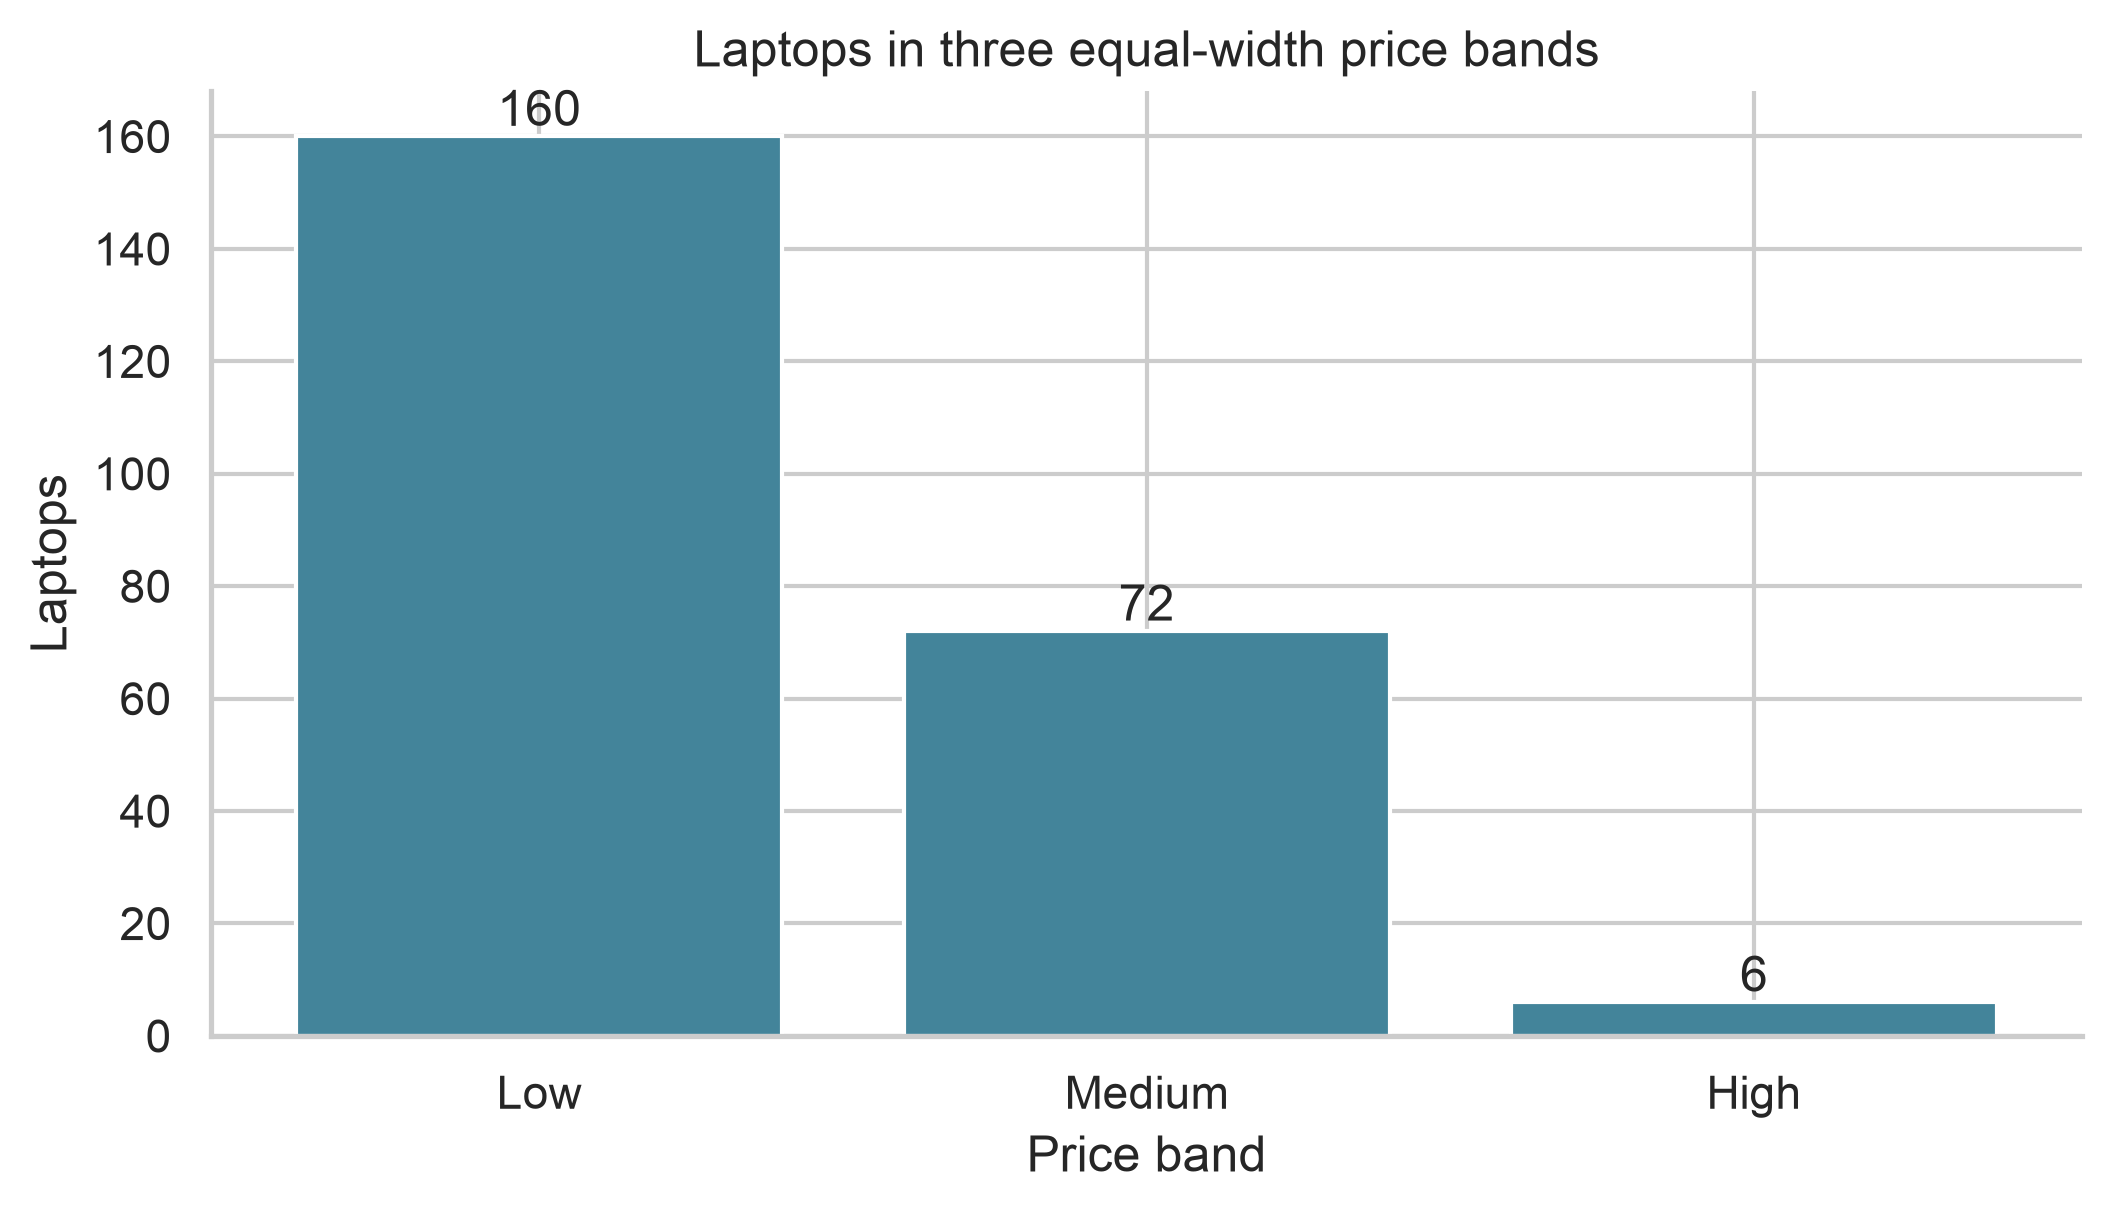

In [14]:
fig, ax = plt.subplots()
ax.bar(group_names, price_counts, color='#43849a')
ax.set(title='Laptops in three equal-width price bands', xlabel='Price band', ylabel='Laptops')
ax.bar_label(ax.containers[0])
fig.tight_layout()
plt.show()

The intervals cover the observed price range and have equal widths, not equal frequencies. `Price-binned` is derived from the target and must not be used to predict `Price`.

# Task - 6

### Indicator variables
Convert the "Screen" attribute of the dataset into 2 indicator variables, "Screen-IPS_panel" and "Screen-Full_HD". Then drop the "Screen" attribute from the dataset.

In [15]:
dummy_variable_1 = pd.get_dummies(df['Screen'], dtype=int)
dummy_variable_1 = dummy_variable_1.rename(columns={'IPS Panel': 'Screen-IPS_panel', 'Full HD': 'Screen-Full_HD'})
df = pd.concat([df, dummy_variable_1], axis=1).drop(columns='Screen')
assert df[['Screen-IPS_panel', 'Screen-Full_HD']].sum(axis=1).eq(1).all()
df[['Screen-IPS_panel', 'Screen-Full_HD']].head()

,Screen-IPS_panel,Screen-Full_HD
0,1,0
1,0,1
2,0,1
3,1,0
4,0,1


This cleaned file documents the transformations in this lab. Subsequent notebooks load their own prescribed `mod2` input snapshot, which need not be byte-identical to this export.

Print the content of dataframe.head() to verify the changes that were made to the dataset.

In [16]:
assert not df.isna().any().any()
assert df['Price-binned'].notna().all()
display(df.head())
output_path = OUTPUT_ROOT / 'datasets/processed/M02/laptops_clean.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False)
print(f'Saved {len(df)} rows to {output_path.name}.')

,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,Acer,4,2,1,5,14.0000,0.5517,8,256,3.5280,978,Low,0,1
1,1,Dell,3,1,1,3,15.5984,0.6897,4,256,4.8510,634,Low,1,0
2,2,Dell,3,1,1,7,15.5984,0.9310,8,256,4.8510,946,Low,1,0
3,3,Dell,4,2,1,5,13.2992,0.5517,8,128,2.6901,1244,Low,0,1
4,4,HP,4,2,1,7,15.5984,0.6207,8,256,4.2115,837,Low,1,0


Saved 238 rows to laptops_clean.csv.


All rows are retained because this snapshot has observed prices. The screen indicators are mutually exclusive and exhaustive; manufacturer names and nominal hardware codes remain categorical features.

## Authors

[Abhishek Gagneja](https://www.coursera.org/instructor/~129186572)

[Vicky Kuo](https://author.skills.network/instructors/vicky_kuo)

Copyright © 2023 IBM Corporation. All rights reserved.

## Tool acknowledgement

OpenAI Codex assisted with code completion, debugging and explanation drafting. Numerical results and figures were generated by executing the notebook in the recorded local Python environment. The collaborators are responsible for reviewing the analysis and submitted material. [OpenAI Codex](https://openai.com/codex/) (accessed 15 September 2026).